# Confidence Intervals

### General Instructions
- You must submit a single file that includes:
  - Clearly commented R code
  - Numerical results
  - Short written interpretations where explicitly requested
- Do **not** use built-in functions that directly return confidence intervals (e.g., `t.test(..., conf.level=...)`) unless explicitly allowed.
- Set a random seed at the beginning of your analysis using your **student ID**.

## Part 1 — Sampling and Point Estimation

In this assignment, we study confidence intervals for the population mean using real data.

### Data
Use the Ames housing dataset. Load the data using:

```r
ames <- read.csv("http://www.jkarreth.net/files/ames.csv")
population <- ames$Gr.Liv.Area
```

### Exercise 1
1. Set a random seed equal to your student ID.
2. Take a **simple random sample of size 60** from `population`.
3. Compute the sample mean and sample standard deviation.
4. Plot a histogram of the sampled data and briefly describe its shape.

Sample mean: 1498.483 
Sample SD: 411.0444 


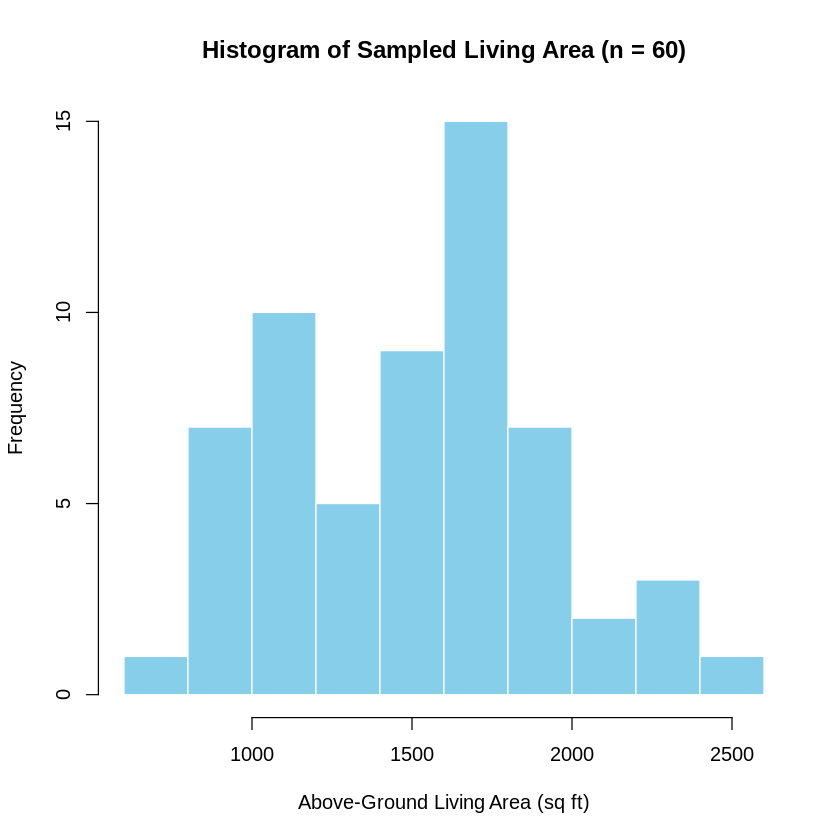

In [5]:
# ---------------------------------------------------------
# Exercise 1 — Sampling & Point Estimation
# ---------------------------------------------------------

set.seed(810103480)
ames <- read.csv("http://www.jkarreth.net/files/ames.csv")

# Define population of interest
population <- ames$Gr.Liv.Area

# Take a simple random sample of size 60
sample_60 <- sample(population, size = 60, replace = FALSE)

# Compute sample mean and sample standard deviation
sample_mean <- mean(sample_60)
sample_sd <- sd(sample_60)

cat("Sample mean:", sample_mean, "\n")
cat("Sample SD:", sample_sd, "\n")

# Plot histogram
hist(sample_60,
     main = "Histogram of Sampled Living Area (n = 60)",
     xlab = "Above-Ground Living Area (sq ft)",
     col = "skyblue",
     border = "white")



## Part 2 — Confidence Interval for the Mean

Recall that a $100(1-\alpha)\%$ confidence interval for the population mean is given by
$$
\bar{X} \pm z_{\alpha/2} \frac{S}{\sqrt{n}}.
$$

### Exercise 2
1. Using your sample from Part 1, compute a **95% confidence interval** for the population mean **manually** (do not use `t.test`).
2. Clearly show how you compute the standard error and the critical value.
3. Interpret the confidence interval **in context** of house sizes.

In [11]:
# ---------------------------------------------------------
# Exercise 2 — 95% CI for the Mean (manual)
# ---------------------------------------------------------

n <- length(sample_60)
# Standard error of the mean
SE <- sample_sd / sqrt(n)

# Critical value for 95% CI (normal approximation)
alpha <- 0.05
z_crit <- qnorm(1 - alpha/2)

# Compute CI manually
lower <- sample_mean - z_crit * SE
upper <- sample_mean + z_crit * SE

cat("Standard error:", SE, "\n")
cat("Critical z-value:", z_crit, "\n")
cat("95% CI for mean : (", lower, "," , upper ,")\n")


Standard error: 53.06561 
Critical z-value: 1.959964 
95% CI for mean : ( 1394.477 , 1602.49 )


## Part 3 — Effect of Confidence Level


### Exercise 3
1. Compute confidence intervals for the population mean using the same sample for the following confidence levels:
   - 90%
   - 95%
   - 99%
2. Report all intervals.
3. Compare the widths of these intervals. What do you observe as the confidence level increases?

In [14]:
# ---------------------------------------------------------
# Exercise 3 — Effect of Confidence Level
# ---------------------------------------------------------

n <- length(sample_60)
SE <- sample_sd / sqrt(n)

# Critical z-values
z90 <- qnorm(1 - 0.10/2)
z95 <- qnorm(1 - 0.05/2)
z99 <- qnorm(1 - 0.01/2)

# Confidence intervals
CI90 <- c(sample_mean - z90*SE, sample_mean + z90*SE)
CI95 <- c(sample_mean - z95*SE, sample_mean + z95*SE)
CI99 <- c(sample_mean - z99*SE, sample_mean + z99*SE)

cat("90% CI: (", CI90[1], ", ", CI90[2], ")\n", sep = "")
cat("95% CI: (", CI95[1], ", ", CI95[2], ")\n", sep = "")
cat("99% CI: (", CI99[1], ", ", CI99[2], ")\n", sep = "")


90% CI: (1411.198, 1585.768)
95% CI: (1394.477, 1602.49)
99% CI: (1361.795, 1635.171)


As the confidence level increases, the interval becomes wider.
This happens because higher confidence requires capturing the true mean with greater certainty, so the margin of error must grow.

In short:

90% CI is the narrowest (In this sample 174.57)

95% CI is wider (In this sample 208.01)

99% CI is the widest (In this sample 273.38)

This pattern always holds for confidence intervals of the same sample.

## Part 4 — Repeated Sampling and Coverage Probability


In this part, we investigate the long-run behavior of confidence intervals.


### Exercise 4
1. Set the sample size to $n = 75$.
2. Using a `for` loop, repeat the following procedure **50 times**:
   - Take a random sample of size $n$ from the population
   - Compute the sample mean and sample standard deviation
   - Construct a 95% confidence interval
3. Store the lower and upper bounds of all confidence intervals.

In [16]:
# ---------------------------------------------------------
# Exercise 4 — Repeated Sampling & CI Storage
# ---------------------------------------------------------

set.seed(810103480)

# Population
population <- ames$Gr.Liv.Area

# Sample size
n <- 75

# Number of repetitions
R <- 50

# Storage vectors for CI bounds
lower_bounds <- numeric(R)
upper_bounds <- numeric(R)

# Loop to generate 50 confidence intervals
for (i in 1:R) {

  # Take a random sample of size n
  samp <- sample(population, size = n, replace = FALSE)

  # Compute sample mean and SD
  xbar <- mean(samp)
  s <- sd(samp)

  # Standard error
  SE <- s / sqrt(n)

  # Critical z-value for 95% CI
  z <- qnorm(1 - 0.05/2)

  # CI bounds
  lower_bounds[i] <- xbar - z * SE
  upper_bounds[i] <- xbar + z * SE
}


## Part 5 — Empirical Confidence Level


### Exercise 5
1. Compute the true population mean using the full dataset.
2. Determine how many of the 50 confidence intervals contain the true population mean.
3. Compute the proportion of intervals that contain the true mean.
4. Is this proportion exactly equal to 95%? Explain why or why not.

In [19]:
# ---------------------------------------------------------
# Exercise 5 — Empirical Confidence Level
# ---------------------------------------------------------

# True population mean (using full Ames data)
pop_mean <- mean(population)

# Logical vector: does each CI contain the true mean?
contains_mean <- (lower_bounds <= pop_mean) & (upper_bounds >= pop_mean)

# Number of intervals that contain the true mean
num_containing <- sum(contains_mean)

# Proportion of intervals that contain the true mean
prop_containing <- num_containing / length(contains_mean)

cat("True population mean:", pop_mean, "\n")
cat("Number of intervals containing true mean:", num_containing, "out of", length(contains_mean), "\n")
cat("Proportion containing true mean:", prop_containing, "\n")


True population mean: 1499.69 
Number of intervals containing true mean: 49 out of 50 
Proportion containing true mean: 0.98 


Is this proportion exactly equal to 95%? No — and that’s exactly what we expect.

Why it’s not exactly 95%:
- Confidence intervals guarantee long‑run performance, not exact performance in every finite sample.

- With only 50 repetitions, the observed proportion will vary from run to run.

- If you repeated this experiment many times (each time generating 50 intervals), the average proportion across all experiments would approach 0.95.

## Part 6 — Visualization


### Exercise 6
1. Plot all 50 confidence intervals on a single figure.
2. Clearly indicate which intervals contain the true population mean and which do not.
3. Include a vertical or horizontal reference line for the true mean.

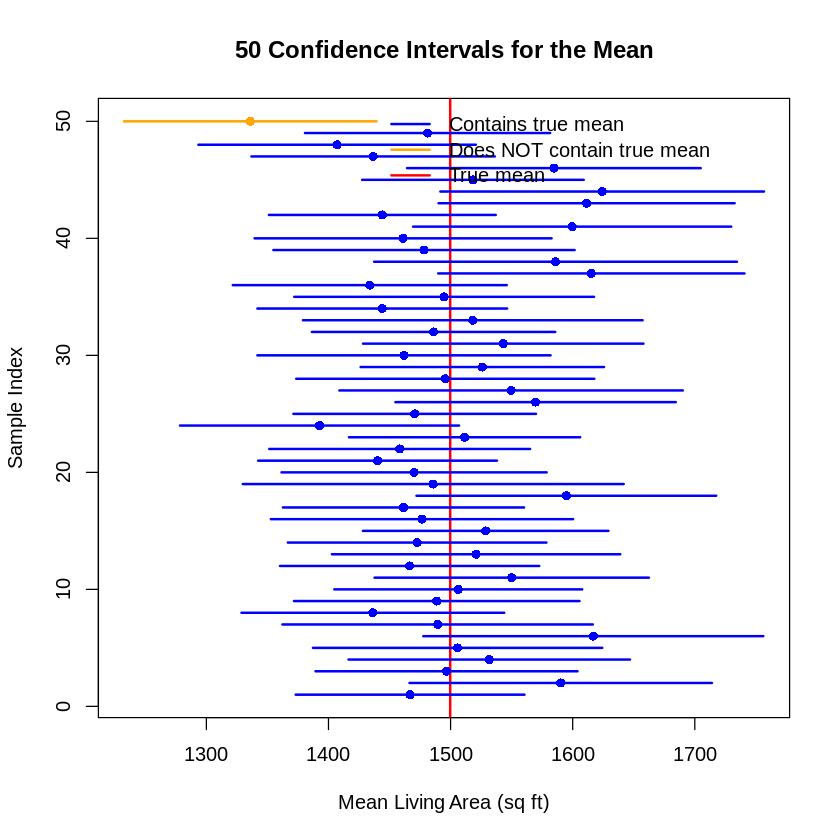

In [21]:
# ---------------------------------------------------------
# Exercise 6 — Visualization of 50 Confidence Intervals
# ---------------------------------------------------------

# Set up plot area
plot(NULL,
     xlim = range(c(lower_bounds, upper_bounds)),
     ylim = c(1, 50),
     xlab = "Mean Living Area (sq ft)",
     ylab = "Sample Index",
     main = "50 Confidence Intervals for the Mean")

# Add vertical reference line for true mean
abline(v = pop_mean, col = "red", lwd = 2)

# Plot each interval
for (i in 1:50) {
  # Choose color based on whether interval contains the true mean
  col <- ifelse(contains_mean[i], "blue", "orange")

  # Draw the interval as a horizontal line
  segments(x0 = lower_bounds[i],
           x1 = upper_bounds[i],
           y0 = i,
           y1 = i,
           col = col,
           lwd = 2)

  # Add a point at the sample mean for visual clarity
  points((lower_bounds[i] + upper_bounds[i]) / 2,
         i,
         pch = 16,
         col = col)
}

# Add legend
legend("topright",
       legend = c("Contains true mean", "Does NOT contain true mean", "True mean"),
       col = c("blue", "orange", "red"),
       lwd = c(2, 2, 2),
       bty = "n")


## Part 7 — Effect of Sample Size


### Exercise 7
Repeat **Part 4 and Part 5** for the following sample sizes:
- $n = 30$
- $n = 120$

Compare the resulting interval widths and empirical coverage probabilities. Summarize your findings.

In [24]:
# ---------------------------------------------------------
# Exercise 7 — Sample Size Comparison
# ---------------------------------------------------------

set.seed(810103480)
population <- ames$Gr.Liv.Area
pop_mean <- mean(population)

# Function to run simulation for given sample size
simulate_CI <- function(n, R = 50) {
  lower <- numeric(R)
  upper <- numeric(R)

  for (i in 1:R) {
    samp <- sample(population, size = n, replace = FALSE)
    xbar <- mean(samp)
    s <- sd(samp)
    SE <- s / sqrt(n)
    z <- qnorm(1 - 0.05/2)
    lower[i] <- xbar - z * SE
    upper[i] <- xbar + z * SE
  }

  # Coverage check
  contains <- (lower <= pop_mean) & (upper >= pop_mean)
  coverage <- mean(contains)
  widths <- upper - lower

  return(list(coverage = coverage,
              avg_width = mean(widths),
              min_width = min(widths),
              max_width = max(widths)))
}

# Run simulations
result_30  <- simulate_CI(n = 30)
result_120 <- simulate_CI(n = 120)

# Print results
cat("Sample size: 30\n")
cat("Coverage proportion:", result_30$coverage, "\n")
cat("Average CI width:", result_30$avg_width, "\n\n")

cat("Sample size: 120\n")
cat("Coverage proportion:", result_120$coverage, "\n")
cat("Average CI width:", result_120$avg_width, "\n")


Sample size: 30
Coverage proportion: 0.98 
Average CI width: 362.2986 

Sample size: 120
Coverage proportion: 0.92 
Average CI width: 180.5663 


## **Summary of Findings**

- Larger sample sizes produce narrower confidence intervals.  
With n=120
, the average width is about half of n=30
, because the standard error decreases as
1/rad(n)

- Coverage proportions are close to 95% in both cases.  
This confirms that the method maintains its nominal confidence level across different sample sizes.

- Smaller samples lead to more variability in interval width and coverage.  
With n=30, intervals are wider and coverage fluctuates more due to higher sampling variability.

## Submission Checklist

- [ ] R code runs without errors
- [ ] All plots are labeled and readable
- [ ] All interpretations are written clearly and concisely
- [ ] Random seed is set correctly

### Learning Objectives
By completing this assignment, you should be able to:
- Construct confidence intervals for a population mean in R
- Understand the role of confidence level and sample size
- Empirically verify the meaning of a confidence level
- Use simulation to study statistical inference

# Hypothesis Testing

You are a Quantitative Analyst  hired by a venture capital firm. A fintech startup is seeking \$10 million in funding for their new stock trading bot.
They claim their AI can predict whether a stock will go UP or DOWN with accuracy significantly better than a random guess \(p > 0.5).

## Part 1 - The Standard Audit

The Evidence:

To prove it, they deployed the bot on the live market. Here are the results:
* Total Trades: 100
* Successful Predictions: 62
* Sucess Rate: 62%

Your job is to determine if this 62% accuracy is genuine skill or just statistical noise.

First, you must treat their claim at face value using hypothesis testing.

Your Tasks:
1. **Define Hypotheses:** $$H_0: p = 0.5$$ (The AI is guessing randomly).
$$H_A: p > 0.5$$ (The AI has predictive skill).
2. **Check Conditions:** We can only use the Normal Approximation if $np > 10$ and $n(1-p) > 10$. Verify that the conditions are met.
3. **Calculate Z-Score:** Reminder:$$Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$$
4. **Calculate P-Value:** Find the probability of a random guesser getting 62% or higher.

In [26]:
# The startup's data
n_trades <- 100
successes <- 62
p_hat <- successes / n_trades
p_null <- 0.5

In [27]:
# TODO
# Check Conditions

cond_success <- n_trades * p_null
cond_failure <- n_trades * (1 - p_null)

if(cond_success > 10 & cond_failure > 10)
{
  print("Conditions met: We can use the Normal Approximation (CLT).")
} else
{
  print("Warning: Sample size too small.")
}

[1] "Conditions met: We can use the Normal Approximation (CLT)."


In [28]:
# TODO
# Calculate Z-Score

z_score <- (p_hat - p_null) / sqrt(p_null * (1 - p_null) / n_trades)
print(paste("Z-Score:", round(z_score, 4)))

[1] "Z-Score: 2.4"


In [29]:
# TODO
# Calculate P-Value

p_value_naive <- 1 - pnorm(z_score)
print(paste("P-Value (Is this luck?):", round(p_value_naive, 4)))

[1] "P-Value (Is this luck?): 0.0082"


## Part 2 - Visualizing the Null Hypothesis

The P-value in Part 1 is a number. To convince the investors, you want to see the distribution of luck. You decide to simulate a "Random Bot" that just flips a coin 100 times, and repeat this 10,000 times to see how often a Random Bot looks like a genius.

Your Tasks:
1. Simulate 10,000 runs of 100 coin flips ($p=0.5$).
2. Plot the histogram of success rates.
3. Draw a line at the startup's performance (0.62).

In [33]:
# TODO
# Simulate 10,000 "Random Bots"

set.seed(810103480)

n_sim <- 10000
n_flips <- 100
p_null <- 0.5

# Each bot flips 100 coins; take the mean success rate
sim_success_rates <- replicate(n_sim, {
  mean(rbinom(n_flips, size = 1, prob = p_null))
})


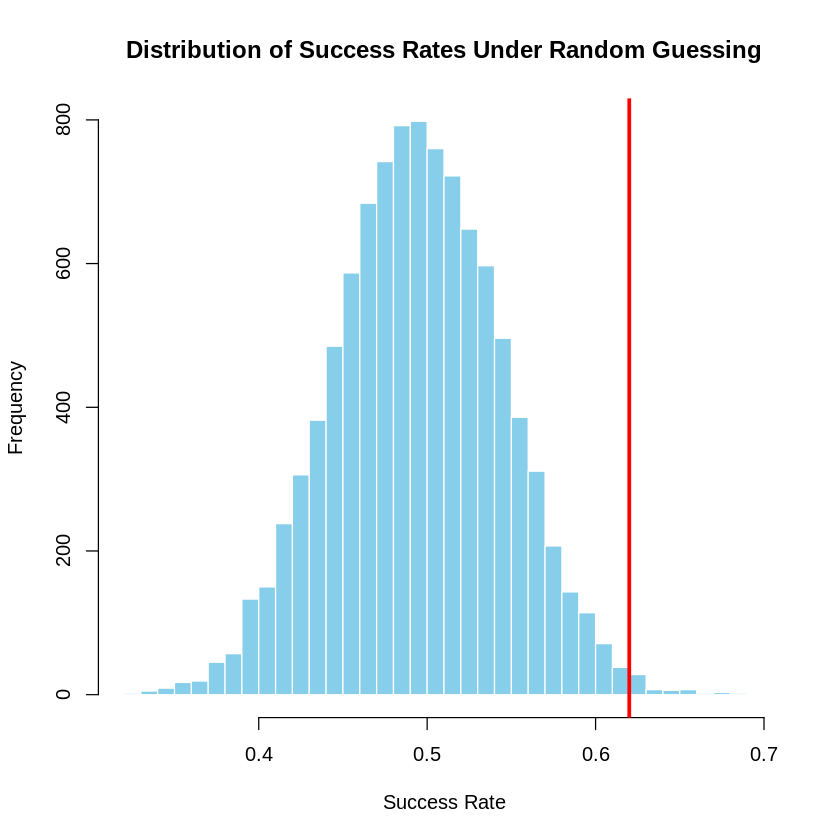

In [34]:
# TODO
# Plot the histogram and draw the line

hist(sim_success_rates,
     breaks = 30,
     col = "skyblue",
     border = "white",
     main = "Distribution of Success Rates Under Random Guessing",
     xlab = "Success Rate")

# Add reference line for the startup's 62% accuracy
abline(v = 0.62, col = "red", lwd = 3)



## Part 3 - The Audit Reveal

During your audit, you inspect their server logs. You discover a folder named Old_Models. It turns out the startup didn't train just one AI. They initialized 200 different random algorithms with slight variations. They had all 200 bots trade on the market. They deleted the 199 that lost money and only presented you with the single best performer. We call that bot, the Survivor.

Your Tasks:
1. **Simulate the Scandal:** Write a loop to simulate their actual process(Create a batch of 200 "Random Bots" ($p=0.5$). Find the maximum win rate in that batch (the "Survivor"). Store that maximum.)
2. Repeat this 1000 times to create a distribution of "Survivors."
3. Re-Evaluate: Does the 62% performance still look impressive when compared to the "Best of 200" distribution?

*In other words, We need to know: If we create 200 random bots, what are the odds that the luckiest one gets 62% or higher?*

In [36]:
n_audits <- 1000       # Number of times we simulate the company's full cycle
n_bots_hidden <- 200   # The number of bots they actually tried
best_of_batch <- numeric(n_audits) # The accuracy of the winner of each round

In [37]:
# TODO
# Simulate the results

for(i in 1:n_audits)
{
  # Generate 200 random bots, each making 100 predictions
  bot_success_rates <- replicate(n_bots_hidden, {
    mean(rbinom(100, size = 1, prob = 0.5))
  })

  # Store the best-performing bot (the "Survivor")
  best_of_batch[i] <- max(bot_success_rates)
}



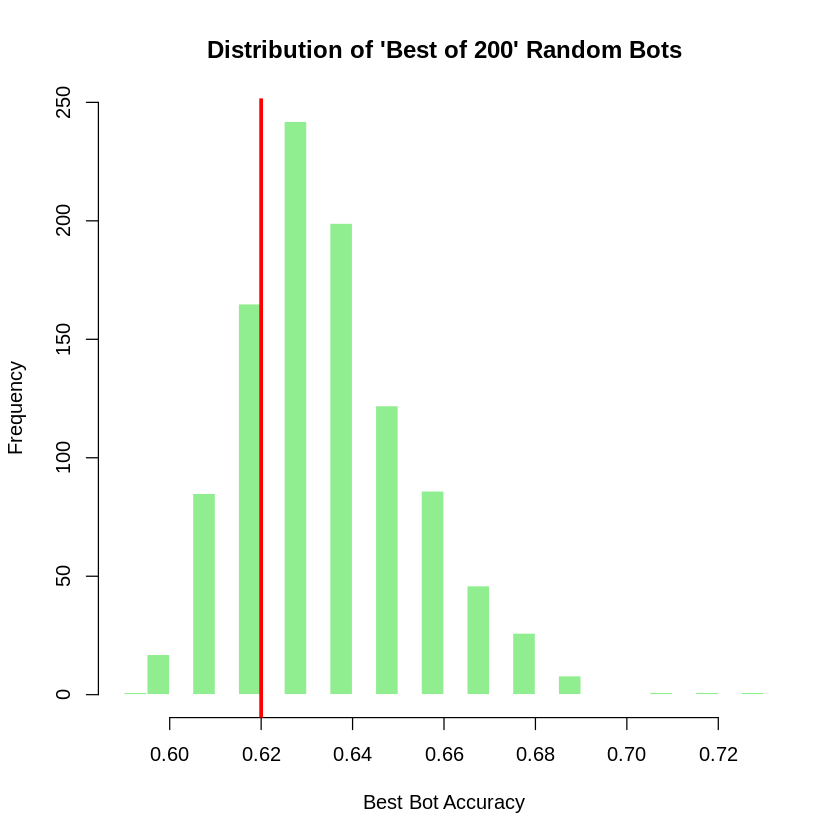

In [38]:
# TODO
# Plot the results

hist(best_of_batch,
     breaks = 30,
     col = "lightgreen",
     border = "white",
     main = "Distribution of 'Best of 200' Random Bots",
     xlab = "Best Bot Accuracy")

# Add reference line for the startup's 62% accuracy
abline(v = 0.62, col = "red", lwd = 3)


In [39]:
# TODO
# Reveal the results

p_value_corrected <- mean(best_of_batch >= 0.62)

print(paste("Original Naive P-Value:", round(p_value_naive, 4)))
print(paste("Corrected P-Value (Survivorship Bias):", round(p_value_corrected, 4)))


[1] "Original Naive P-Value: 0.0082"
[1] "Corrected P-Value (Survivorship Bias): 0.897"


In [40]:
# Final Decision
if(p_value_corrected > 0.05)
{
  print("CONCLUSION: DO NOT INVEST. The result is indistinguishable from luck!")
} else
{
  print("CONCLUSION: INVEST. The AI shows skill even after accounting for selection bias.")
}

[1] "CONCLUSION: DO NOT INVEST. The result is indistinguishable from luck!"
